# 🔍 SpamShield — Hyperparameter Search (Optuna)
**Tujuan:** Menemukan hyperparameter optimal menggunakan Bayesian optimization.  
**Hardware:** RTX 5090 — BF16 mixed precision enabled.

---

## Strategi Pencarian

| Aspek | Nilai |
|---|---|
| Metode | Optuna TPE (Tree-structured Parzen Estimator) |
| Pruner | MedianPruner — potong trial buruk di awal |
| Data | 30% dari train set (proxy untuk kecepatan) |
| Epochs per trial | 3 (proxy metric) |
| Trials | 30 per model (50 untuk Model D) |
| Metric | Validation Macro F1 |
| Precision | BF16 (Blackwell native) |

## Alur Kerja

```
[Optuna Search]     → Temukan hyperparameter terbaik per model
[Save best config]  → best_hyperparams.json
[Full Training]     → spamshield_experiments.ipynb dengan CONFIG baru
```

> **Prerequisite:** `feature_extraction.ipynb` sudah dijalankan  
> (file `train_features.csv`, `val_features.csv`, `test_features.csv` harus ada)


## Cell 1 — Imports & Config

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import optuna
import optuna.visualization as vis
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, accuracy_score
from tqdm.notebook import tqdm
import os, json, warnings, time
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── RTX 5090 Config ────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Verifikasi GPU + BF16
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
    cap      = torch.cuda.get_device_capability(0)
    USE_BF16 = (cap[0] >= 8)  # BF16 supported on Ampere (sm_80) and above
    
    print(f"GPU          : {gpu_name}")
    print(f"VRAM         : {vram_gb:.1f} GB")
    print(f"Capability   : sm_{cap[0]}{cap[1]}")
    print(f"BF16 enabled : {USE_BF16}")
    if cap[0] >= 12:
        print(f"Architecture : Blackwell ✅")
else:
    USE_BF16 = False
    print("⚠️  CUDA not available — running on CPU (very slow)")

print()

# ── Search Config ─────────────────────────────────────────────────────────
SEARCH_CONFIG = {
    # Data
    "train_path"       : "./train_features.csv",
    "val_path"         : "./val_features.csv",
    "text_col"         : "comment_text_normalized",
    "label_col"        : "label",
    "model_name"       : "w11wo/indo-roberta-small",
    "max_length"       : 128,
    "seed"             : 42,

    # Search strategy
    "search_fraction"  : 0.30,    # Pakai 30% train untuk proxy (lebih cepat)
    "n_search_epochs"  : 3,       # Epoch per trial (proxy, bukan final)
    "n_trials_abc"     : 30,      # Trial untuk Model A, B, C
    "n_trials_d"       : 50,      # Trial untuk Model D (proposed)
    
    # Output
    "output_dir"       : "hparam_results",
    "best_config_path" : "best_hyperparams.json",
}

os.makedirs(SEARCH_CONFIG["output_dir"], exist_ok=True)

# ── Fitur ─────────────────────────────────────────────────────────────────
METADATA_FEATURES = [
    "like_count", "reply_count", "channel_subscriber_count",
    "channel_video_count", "channel_view_count",
]
HANDCRAFTED_FEATURES = [
    "text_length", "word_count", "emoji_ratio", "uppercase_ratio",
    "special_char_ratio", "repeat_char_ratio", "unicode_weird_ratio",
    "invisible_char_ratio", "masked_keyword_ratio", "stretched_word_ratio",
    "slang_ratio", "slang_distortion_ratio",
]
NUMERIC_FEATURES = METADATA_FEATURES + HANDCRAFTED_FEATURES  # 17 total

print(f"Numeric features : {len(NUMERIC_FEATURES)}")
print(f"Search fraction  : {SEARCH_CONFIG['search_fraction']*100:.0f}% of train")
print(f"Epochs per trial : {SEARCH_CONFIG['n_search_epochs']}")
print(f"Trials Model D   : {SEARCH_CONFIG['n_trials_d']}")

def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(SEARCH_CONFIG["seed"])

GPU          : NVIDIA GeForce RTX 5090
VRAM         : 34.2 GB
Capability   : sm_120
BF16 enabled : True
Architecture : Blackwell ✅

Numeric features : 17
Search fraction  : 30% of train
Epochs per trial : 3
Trials Model D   : 50


## Cell 2 — Load Dataset + Subset Preparation

In [2]:
tokenizer = AutoTokenizer.from_pretrained(SEARCH_CONFIG["model_name"])

# Load full splits
df_train_full = pd.read_csv(SEARCH_CONFIG["train_path"])
df_val        = pd.read_csv(SEARCH_CONFIG["val_path"])

print(f"Train full : {len(df_train_full):,} rows")
print(f"Val        : {len(df_val):,} rows")
print()

# Subset untuk search (stratified by label)
from sklearn.model_selection import train_test_split

df_search, _ = train_test_split(
    df_train_full,
    train_size=SEARCH_CONFIG["search_fraction"],
    stratify=df_train_full[SEARCH_CONFIG["label_col"]],
    random_state=SEARCH_CONFIG["seed"],
)
df_search = df_search.reset_index(drop=True)

spam_pct = df_search[SEARCH_CONFIG["label_col"]].mean() * 100
print(f"Search subset : {len(df_search):,} rows | SPAM={spam_pct:.1f}%")

# Fit StandardScaler dari subset (bukan full train — karena search pakai subset)
scaler = StandardScaler()
df_search_scaled = df_search.copy()
df_val_scaled    = df_val.copy()

df_search_scaled[NUMERIC_FEATURES] = scaler.fit_transform(df_search[NUMERIC_FEATURES])
df_val_scaled   [NUMERIC_FEATURES] = scaler.transform(df_val[NUMERIC_FEATURES])

print()
print("✅ Data ready untuk hyperparameter search")
print(f"   search/val split: {len(df_search_scaled):,} / {len(df_val_scaled):,}")

Train full : 55,012 rows
Val        : 6,876 rows

Search subset : 16,503 rows | SPAM=6.0%

✅ Data ready untuk hyperparameter search
   search/val split: 16,503 / 6,876


## Cell 3 — Dataset Class + Helper Functions

In [3]:
class SpamDataset(Dataset):
    def __init__(self, df, use_text=True, use_numeric=True):
        self.texts       = df[SEARCH_CONFIG["text_col"]].fillna("").tolist()
        self.labels      = df[SEARCH_CONFIG["label_col"]].tolist()
        self.use_text    = use_text
        self.use_numeric = use_numeric
        if use_numeric:
            self.numeric = df[NUMERIC_FEATURES].values.astype(np.float32)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {"labels": torch.tensor(self.labels[idx], dtype=torch.long)}
        if self.use_text:
            enc = tokenizer(
                self.texts[idx], max_length=SEARCH_CONFIG["max_length"],
                padding="max_length", truncation=True, return_tensors="pt",
            )
            item["input_ids"]      = enc["input_ids"].squeeze(0)
            item["attention_mask"] = enc["attention_mask"].squeeze(0)
        if self.use_numeric:
            item["numeric"] = torch.tensor(self.numeric[idx], dtype=torch.float32)
        return item


def make_loaders(df_train, df_val, batch_size, use_text, use_numeric):
    train_ds = SpamDataset(df_train, use_text, use_numeric)
    val_ds   = SpamDataset(df_val,   use_text, use_numeric)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, drop_last=True,
                              num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size * 2,
                              shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, val_loader


def compute_class_weights(df):
    counts = df[SEARCH_CONFIG["label_col"]].value_counts().sort_index()
    total, C = len(df), len(counts)
    weights = [total / (C * counts[i]) for i in range(C)]
    return torch.tensor(weights, dtype=torch.float32)


def evaluate(model, loader, criterion, use_text, use_numeric):
    model.eval()
    total_loss, preds, labs = 0, [], []
    with torch.no_grad():
        for batch in loader:
            kw = {}
            if use_text:
                kw["input_ids"]      = batch["input_ids"].to(device)
                kw["attention_mask"] = batch["attention_mask"].to(device)
            if use_numeric:
                kw["numeric"] = batch["numeric"].to(device)
            labels = batch["labels"].to(device)
            
            with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                logits = model(**kw)
            
            total_loss += criterion(logits.float(), labels).item()
            preds.extend(torch.argmax(logits, -1).cpu().numpy())
            labs.extend(labels.cpu().numpy())
    
    f1 = f1_score(labs, preds, average="macro", zero_division=0)
    return total_loss / len(loader), f1


print("Helper functions ready")
print(f"  DataLoader  : num_workers=0, pin_memory=False")
print(f"  Mixed prec  : BF16={USE_BF16}")

Helper functions ready
  DataLoader  : num_workers=0, pin_memory=False
  Mixed prec  : BF16=True


## Cell 4 — Model Definitions (Parameterized by Trial)

In [4]:
# Model A — Text Only
class TextOnlyModel(nn.Module):
    def __init__(self, model_name, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        h = self.roberta.config.hidden_size  # 512
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(h, 2))

    def forward(self, input_ids, attention_mask, **kw):
        out = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


# Model B — MLP Only
class MLPOnlyModel(nn.Module):
    def __init__(self, num_features, hidden_dim=64, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(num_features, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),   nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2),
        )
    def forward(self, numeric, **kw): return self.mlp(numeric)


# Model C — Concat Fusion
class ConcatFusionModel(nn.Module):
    def __init__(self, model_name, num_features, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        h = self.roberta.config.hidden_size  # 512
        self.classifier = nn.Sequential(
            nn.Linear(h + num_features, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 2),
        )
    def forward(self, input_ids, attention_mask, numeric, **kw):
        h = self.roberta(input_ids=input_ids, attention_mask=attention_mask
                         ).last_hidden_state[:, 0, :]
        return self.classifier(torch.cat([h, numeric], dim=-1))


# Model D — Gated Fusion (Proposed)
class GatedFusionModel(nn.Module):
    def __init__(self, model_name, num_features, dropout=0.1):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name)
        d = self.roberta.config.hidden_size  # 512
        self.meta_encoder = nn.Sequential(
            nn.Linear(num_features, d), nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d, d),            nn.BatchNorm1d(d), nn.ReLU(), nn.Dropout(dropout),
        )
        self.gate       = nn.Sequential(nn.Linear(d * 2, 1), nn.Sigmoid())
        self.layer_norm = nn.LayerNorm(d)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(d, 2))

    def forward(self, input_ids, attention_mask, numeric, **kw):
        h_t = self.roberta(input_ids=input_ids,
                           attention_mask=attention_mask).last_hidden_state[:, 0, :]
        h_m = self.meta_encoder(numeric)
        α   = self.gate(torch.cat([h_t, h_m], dim=-1))
        h_f = self.layer_norm(α * h_t + (1 - α) * h_m)
        return self.classifier(h_f)

    def get_alpha(self, input_ids, attention_mask, numeric):
        self.eval()
        with torch.no_grad():
            h_t = self.roberta(input_ids=input_ids,
                               attention_mask=attention_mask).last_hidden_state[:, 0, :]
            h_m = self.meta_encoder(numeric)
            return self.gate(torch.cat([h_t, h_m], dim=-1)).squeeze(-1)


def build_model(model_type, dropout):
    N = len(NUMERIC_FEATURES)
    name = SEARCH_CONFIG["model_name"]
    if model_type == "A": return TextOnlyModel(name, dropout)
    if model_type == "B": return MLPOnlyModel(N, dropout=dropout)
    if model_type == "C": return ConcatFusionModel(name, N, dropout)
    if model_type == "D": return GatedFusionModel(name, N, dropout)
    raise ValueError(f"Unknown model: {model_type}")


print("Model A, B, C, D defined (parameterized by dropout)")

Model A, B, C, D defined (parameterized by dropout)


## Cell 5 — Optuna Objective Function

**Search Space:**
| Parameter | Range | Scale |
|---|---|---|
| `lr_roberta` | 5e-6 → 1e-4 | log |
| `lr_multiplier` | 5 → 20 | int |
| `batch_size` | 16, 32, 64 | categorical |
| `dropout` | 0.05 → 0.35 | step 0.05 |
| `weight_decay` | 0.001 → 0.1 | log |
| `warmup_ratio` | 0.05 → 0.25 | float |


In [5]:
def make_objective(model_type, df_search, df_val, class_weights):
    """
    Factory: buat objective function Optuna untuk model tertentu.
    Setiap trial = 1 hyperparameter set, dilatih N_SEARCH_EPOCHS epoch.
    Hasilnya val Macro F1 → Optuna maksimalkan ini.
    """
    use_text    = (model_type != "B")
    use_numeric = (model_type != "A")

    def objective(trial):
        # ── Sample hyperparameters ─────────────────────────────────────────
        lr_roberta    = trial.suggest_float("lr_roberta",   5e-6, 1e-4, log=True)
        lr_mult       = trial.suggest_int("lr_multiplier",  5, 20)
        batch_size    = trial.suggest_categorical("batch_size", [16, 32, 64])
        dropout       = trial.suggest_float("dropout", 0.05, 0.35, step=0.05)
        weight_decay  = trial.suggest_float("weight_decay", 0.001, 0.1, log=True)
        warmup_ratio  = trial.suggest_float("warmup_ratio", 0.05, 0.25)

        # ── Build model ───────────────────────────────────────────────────
        model = build_model(model_type, dropout).to(device)

        # ── DataLoaders ───────────────────────────────────────────────────
        train_loader, val_loader = make_loaders(
            df_search, df_val, batch_size, use_text, use_numeric
        )

        # ── Optimizer ─────────────────────────────────────────────────────
        if use_text and hasattr(model, "roberta"):
            roberta_params = list(model.roberta.parameters())
            other_params   = [p for n, p in model.named_parameters() if "roberta" not in n]
            optimizer = torch.optim.AdamW([
                {"params": roberta_params, "lr": lr_roberta},
                {"params": other_params,   "lr": lr_roberta * lr_mult},
            ], weight_decay=weight_decay)
        else:
            optimizer = torch.optim.AdamW(
                model.parameters(),
                lr=lr_roberta * lr_mult,
                weight_decay=weight_decay,
            )

        total_steps  = SEARCH_CONFIG["n_search_epochs"] * len(train_loader)
        warmup_steps = int(total_steps * warmup_ratio)
        scheduler    = get_cosine_schedule_with_warmup(
            optimizer, warmup_steps, total_steps
        )
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

        # ── Training loop ─────────────────────────────────────────────────
        best_f1 = 0.0

        for epoch in range(SEARCH_CONFIG["n_search_epochs"]):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                kw = {}
                if use_text:
                    kw["input_ids"]      = batch["input_ids"].to(device)
                    kw["attention_mask"] = batch["attention_mask"].to(device)
                if use_numeric:
                    kw["numeric"] = batch["numeric"].to(device)
                labels = batch["labels"].to(device)

                # BF16 mixed precision (Blackwell native)
                with autocast(device_type="cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    logits = model(**kw)
                    loss   = criterion(logits.float(), labels)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

            # ── Validate after each epoch ──────────────────────────────────
            _, val_f1 = evaluate(model, val_loader, criterion, use_text, use_numeric)
            best_f1   = max(best_f1, val_f1)

            # Report ke Optuna untuk pruning
            trial.report(val_f1, epoch)
            if trial.should_prune():
                del model
                torch.cuda.empty_cache()
                raise optuna.exceptions.TrialPruned()

        del model
        torch.cuda.empty_cache()
        return best_f1

    return objective


print("Objective function factory defined")
print("  Search space:")
print("    lr_roberta    : [5e-6, 1e-4]  log")
print("    lr_multiplier : [5, 20]       int")
print("    batch_size    : {16, 32, 64}  categorical")
print("    dropout       : [0.05, 0.35]  step 0.05")
print("    weight_decay  : [0.001, 0.1]  log")
print("    warmup_ratio  : [0.05, 0.25]  float")

Objective function factory defined
  Search space:
    lr_roberta    : [5e-6, 1e-4]  log
    lr_multiplier : [5, 20]       int
    batch_size    : {16, 32, 64}  categorical
    dropout       : [0.05, 0.35]  step 0.05
    weight_decay  : [0.001, 0.1]  log
    warmup_ratio  : [0.05, 0.25]  float


## Cell 6 — Run Hyperparameter Search

⏱️ **Estimasi waktu (RTX 5090):**
- Model A: ~30 trials × ~3 min = ~1.5 jam
- Model B: ~30 trials × ~0.5 min = ~15 menit
- Model C: ~30 trials × ~4 min = ~2 jam
- Model D: ~50 trials × ~4 min = ~3.5 jam
- **Total: ~7-8 jam** (bisa di-run overnight)

> Kamu bisa run per model satu per satu, atau semua sekaligus.


In [6]:
class_weights_search = compute_class_weights(df_search)
best_params_all = {}

def run_search(model_type, n_trials, study_name=None):
    """Jalankan Optuna search untuk 1 model type."""
    print(f"\n{'='*55}")
    print(f"  SEARCHING Model {model_type} | {n_trials} trials")
    print(f"{'='*55}")

    study = optuna.create_study(
        study_name   = study_name or f"spamshield_model_{model_type.lower()}",
        direction    = "maximize",
        sampler      = optuna.samplers.TPESampler(seed=SEARCH_CONFIG["seed"]),
        pruner       = optuna.pruners.MedianPruner(
            n_startup_trials=5,   # Tidak prune 5 trial pertama
            n_warmup_steps=1,     # Beri 1 epoch sebelum bisa prune
            interval_steps=1,
        ),
    )

    objective = make_objective(
        model_type, df_search_scaled, df_val_scaled, class_weights_search
    )

    start = time.time()
    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True,
        gc_after_trial=True,    # GC setelah setiap trial untuk hemat VRAM
    )
    elapsed = time.time() - start

    # ── Print results ──────────────────────────────────────────────────
    best = study.best_trial
    pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])

    print(f"\n  ✅ Search selesai dalam {elapsed/60:.1f} menit")
    print(f"     Complete : {complete} | Pruned : {pruned}")
    print(f"     Best val Macro F1 : {best.value:.4f}")
    print(f"     Best params:")
    for k, v in best.params.items():
        print(f"       {k:<20}: {v}")

    # Simpan ke dict global
    best_params_all[f"model_{model_type}"] = {
        "best_val_f1": best.value,
        "params": best.params,
    }

    # Save study
    study_path = os.path.join(SEARCH_CONFIG["output_dir"],
                              f"study_model_{model_type.lower()}.pkl")
    import pickle
    with open(study_path, "wb") as f:
        pickle.dump(study, f)
    print(f"     Study saved → {study_path}")

    return study


# ── Run searches ──────────────────────────────────────────────────────────
# Jalankan satu per satu — atau hapus comment untuk jalankan semua

print("Memulai hyperparameter search...")
print("Urutan: A → B → C → D")
print("(Bisa dihentikan kapan saja — hasil intermediate tersimpan di best_params_all)")
print()

study_a = run_search("A", SEARCH_CONFIG["n_trials_abc"])

Memulai hyperparameter search...
Urutan: A → B → C → D
(Bisa dihentikan kapan saja — hasil intermediate tersimpan di best_params_all)


  SEARCHING Model A | 30 trials


  0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ✅ Search selesai dalam 20.2 menit
     Complete : 16 | Pruned : 14
     Best val Macro F1 : 0.9746
     Best params:
       lr_roberta          : 3.943590987013728e-05
       lr_multiplier       : 9
       batch_size          : 16
       dropout             : 0.2
       weight_decay        : 0.013499404659630617
       warmup_ratio        : 0.24230435937610456
     Study saved → hparam_results\study_model_a.pkl


In [7]:
study_b = run_search("B", SEARCH_CONFIG["n_trials_abc"])


  SEARCHING Model B | 30 trials


  0%|          | 0/30 [00:00<?, ?it/s]


  ✅ Search selesai dalam 1.8 menit
     Complete : 23 | Pruned : 7
     Best val Macro F1 : 0.9192
     Best params:
       lr_roberta          : 6.86075280820348e-05
       lr_multiplier       : 15
       batch_size          : 16
       dropout             : 0.15000000000000002
       weight_decay        : 0.05765995630232035
       warmup_ratio        : 0.05306112010321313
     Study saved → hparam_results\study_model_b.pkl


In [8]:
study_c = run_search("C", SEARCH_CONFIG["n_trials_abc"])


  SEARCHING Model C | 30 trials


  0%|          | 0/30 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ✅ Search selesai dalam 20.6 menit
     Complete : 18 | Pruned : 12
     Best val Macro F1 : 0.9754
     Best params:
       lr_roberta          : 4.418347455292274e-05
       lr_multiplier       : 14
       batch_size          : 16
       dropout             : 0.3
       weight_decay        : 0.01171019059684262
       warmup_ratio        : 0.11374851919923137
     Study saved → hparam_results\study_model_c.pkl


In [9]:
study_d = run_search("D", SEARCH_CONFIG["n_trials_d"])


  SEARCHING Model D | 50 trials


  0%|          | 0/50 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: w11wo/indo-roberta-small
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



  ✅ Search selesai dalam 32.9 menit
     Complete : 16 | Pruned : 34
     Best val Macro F1 : 0.9734
     Best params:
       lr_roberta          : 3.1245160951798184e-05
       lr_multiplier       : 5
       batch_size          : 16
       dropout             : 0.25
       weight_decay        : 0.07371056161277793
       warmup_ratio        : 0.12865502546101906
     Study saved → hparam_results\study_model_d.pkl


## Cell 7 — Simpan Best Hyperparameters

In [10]:
# Simpan semua best params ke JSON
config_path = SEARCH_CONFIG["best_config_path"]
with open(config_path, "w") as f:
    json.dump(best_params_all, f, indent=2)

print(f"✅ Best hyperparameters saved → {config_path}")
print()
print(json.dumps(best_params_all, indent=2))

✅ Best hyperparameters saved → best_hyperparams.json

{
  "model_A": {
    "best_val_f1": 0.9746246532540302,
    "params": {
      "lr_roberta": 3.943590987013728e-05,
      "lr_multiplier": 9,
      "batch_size": 16,
      "dropout": 0.2,
      "weight_decay": 0.013499404659630617,
      "warmup_ratio": 0.24230435937610456
    }
  },
  "model_B": {
    "best_val_f1": 0.9192170477772366,
    "params": {
      "lr_roberta": 6.86075280820348e-05,
      "lr_multiplier": 15,
      "batch_size": 16,
      "dropout": 0.15000000000000002,
      "weight_decay": 0.05765995630232035,
      "warmup_ratio": 0.05306112010321313
    }
  },
  "model_C": {
    "best_val_f1": 0.9753600446613807,
    "params": {
      "lr_roberta": 4.418347455292274e-05,
      "lr_multiplier": 14,
      "batch_size": 16,
      "dropout": 0.3,
      "weight_decay": 0.01171019059684262,
      "warmup_ratio": 0.11374851919923137
    }
  },
  "model_D": {
    "best_val_f1": 0.9733843825701862,
    "params": {
      "lr_rob

## Cell 8 — Visualisasi Hasil Search

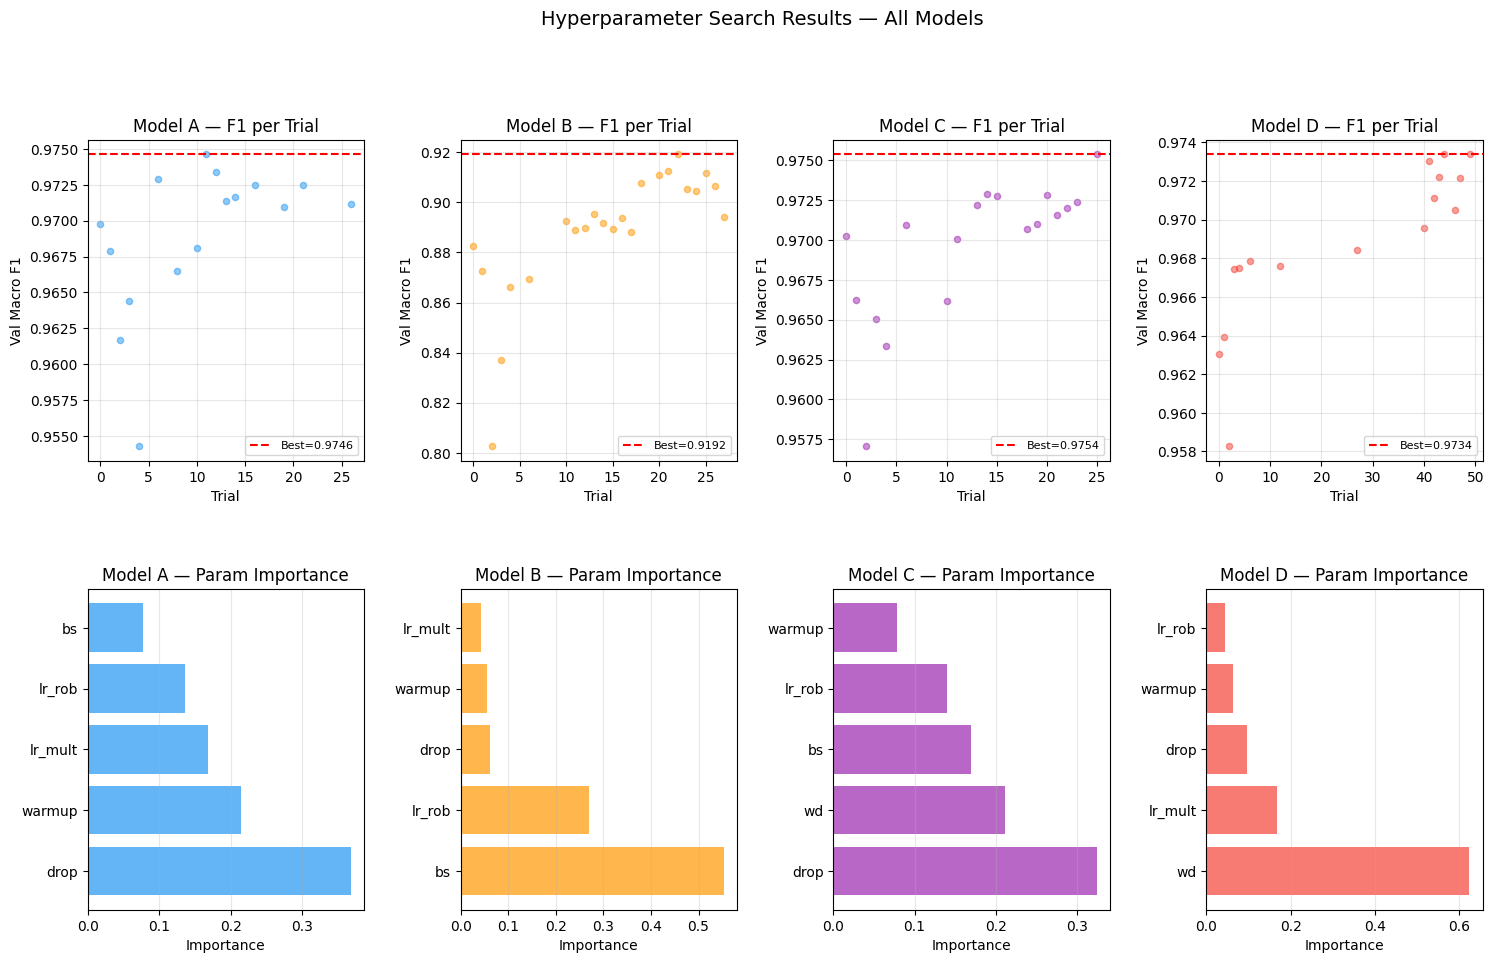

Plot saved.


In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

studies = [("A", study_a), ("B", study_b), ("C", study_c), ("D", study_d)]
colors  = ["#2196F3", "#FF9800", "#9C27B0", "#F44336"]

for idx, (name, study) in enumerate(studies):
    ax_hist = fig.add_subplot(gs[0, idx])
    ax_imp  = fig.add_subplot(gs[1, idx])

    # ── 1. F1 per trial ───────────────────────────────────────────────────
    completed = [t for t in study.trials
                 if t.state == optuna.trial.TrialState.COMPLETE]
    trial_nums = [t.number for t in completed]
    f1_vals    = [t.value  for t in completed]

    ax_hist.scatter(trial_nums, f1_vals, color=colors[idx], alpha=0.5, s=20)
    ax_hist.axhline(y=study.best_value, color="red", linestyle="--",
                    linewidth=1.5, label=f"Best={study.best_value:.4f}")
    ax_hist.set_xlabel("Trial")
    ax_hist.set_ylabel("Val Macro F1")
    ax_hist.set_title(f"Model {name} — F1 per Trial")
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    # ── 2. Parameter importance ───────────────────────────────────────────
    try:
        importance = optuna.importance.get_param_importances(study)
        params = list(importance.keys())[:5]  # Top 5
        imps   = [importance[p] for p in params]
        # Shorten param names
        short_params = [p.replace("lr_roberta","lr_rob")
                         .replace("lr_multiplier","lr_mult")
                         .replace("weight_decay","wd")
                         .replace("batch_size","bs")
                         .replace("warmup_ratio","warmup")
                         .replace("dropout","drop") for p in params]
        bars = ax_imp.barh(short_params, imps, color=colors[idx], alpha=0.7)
        ax_imp.set_xlabel("Importance")
        ax_imp.set_title(f"Model {name} — Param Importance")
        ax_imp.grid(True, alpha=0.3, axis="x")
    except Exception as e:
        ax_imp.text(0.5, 0.5, f"Importance\nN/A\n{str(e)[:30]}",
                    ha="center", va="center", transform=ax_imp.transAxes)
        ax_imp.set_title(f"Model {name} — Param Importance")

plt.suptitle("Hyperparameter Search Results — All Models", fontsize=14, y=1.01)
plt.savefig(os.path.join(SEARCH_CONFIG["output_dir"], "hparam_search_results.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

## Cell 9 — Update CONFIG untuk Final Training

In [12]:
# Load best params
with open(SEARCH_CONFIG["best_config_path"]) as f:
    best_params_all = json.load(f)

print("=" * 60)
print("  BEST HYPERPARAMETERS — Copy ke spamshield_experiments.ipynb")
print("=" * 60)

# Model D (proposed) params
if "model_D" in best_params_all:
    dp = best_params_all["model_D"]["params"]
    
    print(f"""
CONFIG = {{
    "model_name"   : "w11wo/indo-roberta-small",
    "max_length"   : 128,
    "batch_size"   : {dp.get('batch_size', 32)},           # ← dari search
    "learning_rate": {dp.get('lr_roberta', 2e-5):.2e},    # ← dari search (RoBERTa)
    "lr_multiplier": {dp.get('lr_multiplier', 10)},        # ← head LR = lr * multiplier
    "weight_decay" : {dp.get('weight_decay', 0.01):.4f},  # ← dari search
    "warmup_ratio" : {dp.get('warmup_ratio', 0.1):.3f},   # ← dari search
    "dropout"      : {dp.get('dropout', 0.1):.2f},         # ← dari search
    "epochs"       : 10,
    ...
}}""")

    print()
    print("Val F1 dari search (proxy, 30% data, 3 epochs):")
    for model_key, info in best_params_all.items():
        print(f"  {model_key}: {info['best_val_f1']:.4f}")
    
    print()
    print("⚠️  CATATAN:")
    print("  Search menggunakan 30% data & 3 epochs → angka F1 ini proxy.")
    print("  Final F1 akan lebih tinggi saat training full data 10 epochs.")
    print()
    print("  Salin CONFIG di atas ke Cell 1 di spamshield_experiments.ipynb,")
    print("  lalu jalankan full training.")

  BEST HYPERPARAMETERS — Copy ke spamshield_experiments.ipynb

CONFIG = {
    "model_name"   : "w11wo/indo-roberta-small",
    "max_length"   : 128,
    "batch_size"   : 16,           # ← dari search
    "learning_rate": 3.12e-05,    # ← dari search (RoBERTa)
    "lr_multiplier": 5,        # ← head LR = lr * multiplier
    "weight_decay" : 0.0737,  # ← dari search
    "warmup_ratio" : 0.129,   # ← dari search
    "dropout"      : 0.25,         # ← dari search
    "epochs"       : 10,
    ...
}

Val F1 dari search (proxy, 30% data, 3 epochs):
  model_A: 0.9746
  model_B: 0.9192
  model_C: 0.9754
  model_D: 0.9734

⚠️  CATATAN:
  Search menggunakan 30% data & 3 epochs → angka F1 ini proxy.
  Final F1 akan lebih tinggi saat training full data 10 epochs.

  Salin CONFIG di atas ke Cell 1 di spamshield_experiments.ipynb,
  lalu jalankan full training.


---
## ✅ Checklist

| # | Item | Status |
|---|---|---|
| 1 | Optuna TPE + MedianPruner | ✅ |
| 2 | BF16 mixed precision (Blackwell) | ✅ |
| 3 | Search pada 30% subset (proxy cepat) | ✅ |
| 4 | Evaluate pada full val set | ✅ |
| 5 | GC setelah setiap trial | ✅ |
| 6 | Save best_hyperparams.json | ✅ |
| 7 | Visualisasi F1 per trial + param importance | ✅ |
| 8 | Print ready-to-copy CONFIG | ✅ |

**Setelah search selesai:**
1. Copy CONFIG dari Cell 9 → `spamshield_experiments.ipynb` Cell 1
2. Jalankan full training dengan hyperparameter optimal
